# Fig 14

In [1]:
from data_import import *
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from plotting import *

device = 'cuda:0'

In [2]:
df_orig = load_result_table('feeds/T32_L32_2layer').reset_index()
#df_orig = df_orig[df_orig['epoch']==499]
figure_dir = FIGURE_DIR

In [3]:
df_orig

,name,_runtime,_step,_timestamp,_wandb,epoch,params_count,train_loss,val_acc,val_loss,...,batch_size,no_softmax,num_samples,dataset_type,project_name,attention_input,offline_learning,include_validation,entity,project
0,devout-donkey-5880,2670.467008,1000,1.734379e+09,{'runtime': 2669},999,120715,0.013094,99.980053,0.002037,...,32,False,10000,backward_BOS,T32_L32_2layer,only_sem,False,True,feeds,T32_L32_2layer
1,whole-microwave-5879,2652.791057,1000,1.734376e+09,{'runtime': 2652},999,44811,0.014830,99.190731,0.027689,...,32,False,10000,backward_BOS,T32_L32_2layer,only_sem,False,True,feeds,T32_L32_2layer
2,revived-breeze-5878,2648.731682,1000,1.734374e+09,{'runtime': 2647},999,19147,0.044224,99.584442,0.016284,...,32,False,10000,backward_BOS,T32_L32_2layer,only_sem,False,True,feeds,T32_L32_2layer
3,celestial-sea-5877,2679.059680,1000,1.734371e+09,{'runtime': 2678},999,9387,0.022402,100.000000,0.000639,...,32,False,10000,backward_BOS,T32_L32_2layer,only_sem,False,True,feeds,T32_L32_2layer
4,wandering-galaxy-5876,2660.800484,1000,1.734368e+09,{'runtime': 2659},999,5275,0.021276,100.000000,0.000531,...,32,False,10000,backward_BOS,T32_L32_2layer,only_sem,False,True,feeds,T32_L32_2layer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5875,elated-water-5,2646.430424,1000,1.731599e+09,{'runtime': 2645},999,260,2.127463,21.478914,2.129691,...,32,True,10000,backward,T32_L32_2layer,linear,False,True,feeds,T32_L32_2layer
5876,soft-smoke-4,2784.596186,1000,1.731599e+09,{'runtime': 2783},999,65,2.153659,19.921638,2.156279,...,32,False,10000,backward_BOS,T32_L32_2layer,only_sem,False,True,feeds,T32_L32_2layer
5877,bright-frost-3,2741.631342,1000,1.731599e+09,{'runtime': 2741},999,65,1.954324,24.980054,1.956086,...,32,True,10000,backward_BOS,T32_L32_2layer,only_sem,False,True,feeds,T32_L32_2layer
5878,serene-glade-2,2726.215757,1000,1.731599e+09,{'runtime': 2726},999,64,2.144083,21.060981,2.148241,...,32,False,10000,backward,T32_L32_2layer,only_sem,False,True,feeds,T32_L32_2layer


In [4]:
allowed_p = [1,3, 6, 11, 23, 45, 91, 2,4,8,16,32,64,128]#,
allowed_model_dim = [1,3, 6, 11, 23, 45, 91, 2,4,8,16,32,64,128]#,

df_orig = df_orig[df_orig['p'].isin(allowed_p) & df_orig['model_dim'].isin(allowed_model_dim)]
df_orig.model_dim.unique(), df_orig.p.unique()

(array([128,  64,  32,  16,   8,   4,   2,  91,  45,  23,  11,   6,   3,
          1]),
 array([128,  64,  32,  16,   8,   4,   2,  91,  45,  23,  11,   6,   3,
          1]))

In [5]:
df = df_orig.groupby(CONFIG_COLS).mean(numeric_only=True).reset_index()
df_std = df_orig.groupby(CONFIG_COLS).std(numeric_only=True).reset_index()
df_max = df_orig.groupby(CONFIG_COLS).max(numeric_only=True).reset_index()

In [10]:
df.seq_len

0       10
1       10
2       10
3       10
4       10
        ..
1171    10
1172    10
1173    10
1174    10
1175    10
Name: seq_len, Length: 1176, dtype: int64

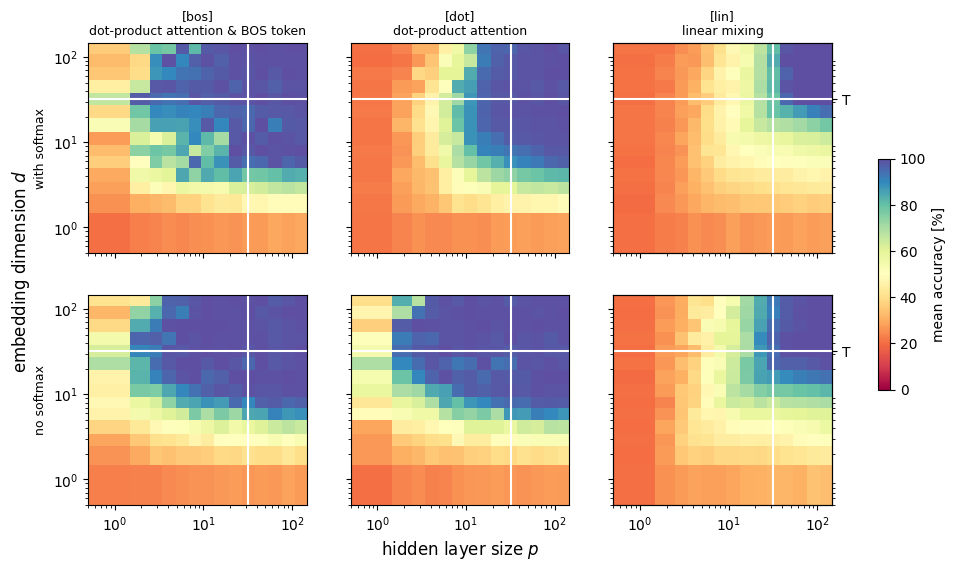

In [11]:
T = 32
L = 10
k = df[(df['T'] == T) & (df.seq_len == L) ]
k_std = df_std[(df_std['T'] == T) & (df_std.seq_len == L) ]
k_max = df_max[(df_std['T'] == T) & (df_std.seq_len == L) ]

fig, axes = plt.subplots(2,3,figsize=(12,6),sharex=True,sharey=True)

axes_assignment = {
        'linear': (1,2),
        'linear+sftm': (0,2),
        'dot': (1,1),
        'dot+sftm': (0,1),
        'dotBOS' : (1,0),
        'dotBOS+sftm': (0,0),
}

axes[axes_assignment['linear+sftm']].set_title('[lin]\nlinear mixing',fontsize=9)
axes[axes_assignment['dot+sftm']].set_title('[dot]\ndot-product attention',fontsize=9)
axes[axes_assignment['dotBOS+sftm']].set_title('[bos]\ndot-product attention & BOS token',fontsize=9)

axes[1,0].set_ylabel('no softmax',fontsize=9)
axes[0,0].set_ylabel('with softmax',fontsize=9)
axes[1,1].set_xlabel('hidden layer size $p$',fontsize=12)


for name, model_config in MODELS.items():
    ax = axes[axes_assignment[name]]
    a = k[(k.attention_input == model_config['attention_input'])
            & (k.no_softmax == model_config['no_softmax']) 
            & (k.dataset_type == model_config['dataset'])]
    a_std = k_std[(k_std.attention_input == model_config['attention_input'])
            & (k_std.no_softmax == model_config['no_softmax']) 
            & (k_std.dataset_type == model_config['dataset'])]
    a_max = k_max[(k_max.attention_input == model_config['attention_input'])
                & (k_max.no_softmax == model_config['no_softmax']) 
                & (k_max.dataset_type == model_config['dataset'])]
    
    if len(a) == 0:
        continue

    aother = pd.pivot_table(a, index='p', columns='model_dim', values='val_acc')
    smap = ax.pcolor(aother.index, aother.columns, aother.values.T, cmap='Spectral', vmin=0, vmax=100)
    #aother_max = pd.pivot_table(a_max, index='p', columns='model_dim', values='best_val_acc')
    
    
    smap = ax.pcolor(aother.index, aother.columns, aother.values.T, cmap='Spectral', vmin=0, vmax=100)
    
    ax.axvline(T,c='white')
    ax.axhline(T,c='white')
    #ax.axhline(np.log(T)+1,c='white')
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    if 'linear' in name:
        ax2 = ax.twinx()
        ax2.set_yscale('log')
        ax2.set_ylim(ax.get_ylim())
        ax2.set_yticks([T])
        ax2.set_yticklabels(['T'])
fig.text(0.06, 0.5, 'embedding dimension $d$', va='center', rotation='vertical',fontsize=12)
fig.colorbar(smap,ax=axes,location='right',shrink=0.5,label='mean accuracy [%]')
plt.savefig(figure_dir / 'memorizing_counts-phase-diagram-T32-L10--2layermean.png',bbox_inches='tight')
plt.show()